# Import libraries

In [ ]:
!pip install -q kaggle

In [ ]:
!pip install split-folders python-resize-image

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import splitfolders
import random
import tensorflow as tf
import tensorflow_hub as hub
import pathlib
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from resizeimage import resizeimage
from IPython.display import Image, display
from PIL import Image
from glob import glob
import kagglehub

# Upload datasets

In [ ]:
from google.colab import files

files.upload()

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download smaranjitghose/corn-or-maize-leaf-disease-dataset

In [ ]:
!mkdir dataset
!mkdir dataset/train
!mkdir dataset/dev
!mkdir dataset/test
!mkdir data0

In [ ]:
!unzip '/content/corn-or-maize-leaf-disease-dataset.zip' -d '/content/data0'

Archive:  /content/corn-or-maize-leaf-disease-dataset.zip
  inflating: /content/data0/data/Blight/Corn_Blight (1).jpeg  
  inflating: /content/data0/data/Blight/Corn_Blight (1).jpg  
  inflating: /content/data0/data/Blight/Corn_Blight (10).jpg  
  inflating: /content/data0/data/Blight/Corn_Blight (100).jpg  
  inflating: /content/data0/data/Blight/Corn_Blight (1000).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1001).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1002).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1003).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1004).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1005).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1006).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1007).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1008).JPG  
  inflating: /content/data0/data/Blight/Corn_Blight (1009).JPG  
  inflating: /content/data0/data/Blight/

### Split the dataset

In [ ]:
#Split the data into 200 for each dev and test, the remainded will be for training purposes

splitfolders.fixed('/content/data0/data', output="output_data", seed=42, fixed=(200, 200))

# splitfolders.ratio('dirty_data', output="output_data", seed=42, ratio=(.7, .15, .15), group_prefix=None)

Copying files: 4188 files [00:00, 6249.78 files/s]


In [ ]:
!mv output_data/train/* dataset/train
!mv output_data/val/* dataset/dev
!mv output_data/test/* dataset/test

!rm -rf output_data
!rm -rf data0

### Test the split worked

In [ ]:
def show_random_images_from(glob_path, seed):
    if seed:
        random.seed(seed)
        randomsample = random.sample(glob(glob_path), 8)
        plt.figure(figsize=(10, 6))
        for i, j in enumerate(randomsample):
            plt.subplot(2, 4, i + 1)
            plt.imshow(Image.open(j))
            plt.axis('off')

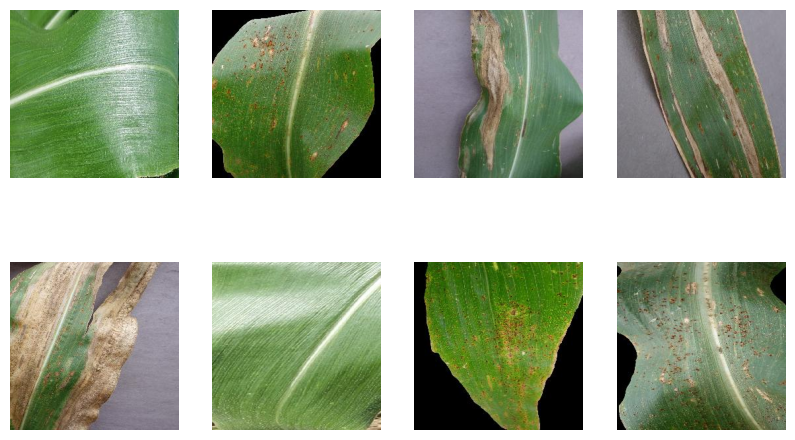

In [ ]:
show_random_images_from('/content/dataset/*/*/*', seed=42)

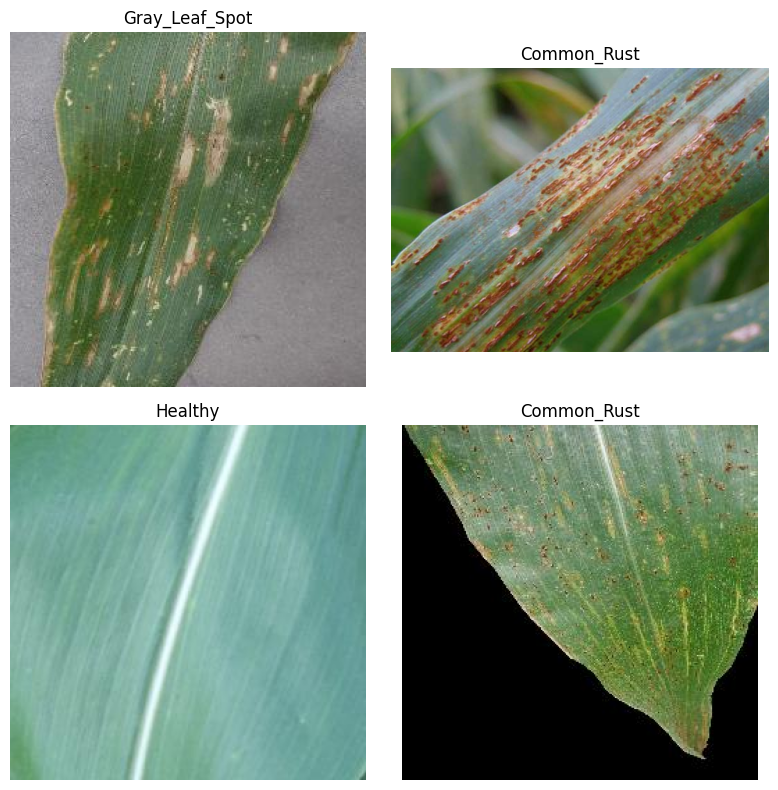

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = "dataset/train"
classes = os.listdir(train_dir)

fig, axes = plt.subplots(2, 2, figsize=(8,8))
for ax in axes.flatten():
    cls = random.choice(classes)
    img_path = os.path.join(train_dir, cls, random.choice(os.listdir(os.path.join(train_dir, cls))))
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()

# Preprocessing Image

In [ ]:
for i, j in enumerate(glob('dataset/*/*/*')):
    try:
        image = Image.open(j)
        cover = resizeimage.resize_cover(image, [224, 224])
        cover.save(j, image.format)
    except:
        print(j, 'error.')

In [ ]:
root_dir = '/content/dataset'
train_dir = os.path.join(root_dir, 'train')
dev_dir = os.path.join(root_dir, 'dev')
test_dir = os.path.join(root_dir, 'test')

handle_base, pixels, FV_SIZE = ("mobilenet_v2", 224, 1280)  # example model details

# Use the path to the TensorFlow Lite model
path = kagglehub.model_download("google/mobilenet-v2/tensorFlow2/tf2-preview-feature-vector")

# Load the TensorFlow Lite model
# interpreter = tf.lite.Interpreter(model_path=path)
# interpreter.allocate_tensors()

# # Get input and output tensor details
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()


100%|██████████| 5.15k/5.15k [00:00<00:00, 6.54MB/s]



  0%|          | 0.00/8.65M [00:00<?, ?B/s]



  0%|          | 0.00/1.10M [00:00<?, ?B/s]
 12%|█▏        | 1.00M/8.65M [00:00<00:03, 2.64MB/s]
 35%|███▍      | 3.00M/8.65M [00:00<00:00, 7.31MB/s]
100%|██████████| 8.65M/8.65M [00:00<00:00, 14.6MB/s]


100%|██████████| 1.10M/1.10M [00:00<00:00, 2.61MB/s]


In [ ]:
print(path)

/root/.cache/kagglehub/models/google/mobilenet-v2/tensorFlow2/tf2-preview-feature-vector/4


In [ ]:
# # Set up directories and parameters
# root_dir = '/content/dataset'
# train_dir = os.path.join(root_dir, 'train')
# dev_dir = os.path.join(root_dir, 'dev')
# test_dir = os.path.join(root_dir, 'test')

# handle_base, pixels, FV_SIZE = ("inception_v2", 299, 2048) #@param ["(\"mobilenet_v2\", 224, 1280)", "(\"inception_v2\", 299, 2048)"] {type: "raw", allow-input: true}

# path = kagglehub.model_download("tensorflow/mobilenet-v2/tfLite/1-0-224")

# # Use a valid TensorFlow Hub module URL
MODULE_HANDLE = path
IMAGE_SIZE = (pixels, pixels)

print(f"Using {MODULE_HANDLE} with input size {IMAGE_SIZE} and output dimension {FV_SIZE}")

Using /root/.cache/kagglehub/models/google/mobilenet-v2/tensorFlow2/tf2-preview-feature-vector/4 with input size (224, 224) and output dimension 1280


# Image Generator

In [ ]:
dir = os.listdir('/content/dataset/dev/Blight')
print(dir)

['Corn_Blight (967).JPG', 'Corn_Blight (1064).JPG', 'Corn_Blight (509).JPG', 'Corn_Blight (1004).JPG', 'Corn_Blight (389).JPG', 'Corn_Blight (562).JPG', 'Corn_Blight (790).JPG', 'Corn_Blight (843).JPG', 'Corn_Blight (638).jpg', 'Corn_Blight (196).JPG', 'Corn_Blight (194).JPG', 'Corn_Blight (10).jpg', 'Corn_Blight (827).JPG', 'Corn_Blight (1087).JPG', 'Corn_Blight (440).JPG', 'Corn_Blight (336).JPG', 'Corn_Blight (81).jpg', 'Corn_Blight (316).JPG', 'Corn_Blight (577).JPG', 'Corn_Blight (96).jpg', 'Corn_Blight (609).JPG', 'Corn_Blight (243).JPG', 'Corn_Blight (109).jpg', 'Corn_Blight (69).jpg', 'Corn_Blight (953).JPG', 'Corn_Blight (183).JPG', 'Corn_Blight (1103).jpg', 'Corn_Blight (80).jpg', 'Corn_Blight (500).JPG', 'Corn_Blight (619).JPG', 'Corn_Blight (186).JPG', 'Corn_Blight (734).JPG', 'Corn_Blight (339).jpg', 'Corn_Blight (775).JPG', 'Corn_Blight (761).JPG', 'Corn_Blight (1065).JPG', 'Corn_Blight (928).jpg', 'Corn_Blight (855).JPG', 'Corn_Blight (640).JPG', 'Corn_Blight (341).JPG',

In [ ]:
BATCH_SIZE = 64

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest',
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
)

valid_generator = valid_datagen.flow_from_directory(
    dev_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
)

Found 2588 images belonging to 4 classes.
Found 800 images belonging to 4 classes.
Found 800 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

class_names = list(train_generator.class_indices.keys())

with open('labels.txt', 'w') as file:
    file.write("\n".join(class_names))

# Define the feature extractor using TensorFlow Hub
feature_extractor = hub.KerasLayer(MODULE_HANDLE, input_shape=IMAGE_SIZE + (3,), output_shape=[FV_SIZE], trainable=False)


print(f"Loaded module: {MODULE_HANDLE}")

# Build the model
from tensorflow.keras.layers import Lambda

# Wrap KerasLayer in a Lambda to make it Keras compatible
model = Sequential([
    Input(shape=IMAGE_SIZE + (3,)),
    Lambda(lambda x: feature_extractor(x)),
    Dense(64, activation='relu'),
    Dense(len(train_generator.class_indices), activation='softmax')
])

# Display the model summary
model.summary()

Loaded module: /root/.cache/kagglehub/models/google/mobilenet-v2/tensorFlow2/tf2-preview-feature-vector/4


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,244 (321.27 KB)

 Trainable params: 82,244 (321.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "dataset/train", target_size=(224,224), batch_size=32, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    "dataset/dev", target_size=(224,224), batch_size=32, class_mode='categorical'
)

# Simple CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


Found 2588 images belonging to 4 classes.
Found 800 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 40s 420ms/step - accuracy: 0.6563 - loss: 4.4988 - val_accuracy: 0.6925 - val_loss: 0.5866
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 365ms/step - accuracy: 0.8901 - loss: 0.3239 - val_accuracy: 0.7100 - val_loss: 0.6254
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 379ms/step - accuracy: 0.8970 - loss: 0.2796 - val_accuracy: 0.7287 - val_loss: 0.5915
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 372ms/step - accuracy: 0.9000 - loss: 0.2860 - val_accuracy: 0.7113 - val_loss: 0.6073
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 376ms/step - accuracy: 0.8787 - loss: 0.3148 - val_accuracy: 0.7287 - val_loss: 0.6102
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 362ms/step - accuracy: 0.9059 - loss: 0.2571 - val_accuracy: 0.7200 - val_loss: 0.6279
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 379ms/step - accuracy: 0.9109 - loss: 0.2338 - val_accuracy: 0.7875 - val_loss: 0.4776
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 367ms/step - accuracy: 0.9115 - loss: 0.2362 - val_accu